# 1. Data Preprocessing

In [1]:
import pandas as pd

df = pd.read_csv("data_Prix_2025.csv", sep="\t", encoding="utf-8-sig")

print(df.head())
print(df.info())
print(df.shape)

                              filename       surname       name  year edition  \
0   edition10/edition10_sequence_0.mp4  Chérittwizer    Valérie  1982    10th   
1   edition10/edition10_sequence_1.mp4         Felix       Tara  1982    10th   
2  edition10/edition10_sequence_10.mp4     Giannetti   Maurizio  1982    10th   
3  edition10/edition10_sequence_11.mp4     Sadamatsu  Shoichiro  1982    10th   
4  edition10/edition10_sequence_12.mp4    Guiderdoni    Thierry  1982    10th   

  dancer_id countries  perf_type  \
0  1982-014    France  classical   
1  1982-002       USA  classical   
2  1982-056     Italy  classical   
3  1982-054     Japan  classical   
4  1982-064    France  classical   

                                              awards  has_award  \
0                                                NaN        0.0   
1                                                NaN        0.0   
2  Bourse pour une année d'enseignement (Prix de ...        1.0   
3  Bourse pour une année d'e

In [2]:
import pandas as pd

df = pd.read_csv("data_Prix_2025.csv", sep="\t", encoding="utf-8-sig")

nan_counts = df.isna().sum()
print(nan_counts)

filename                     0
surname                    217
name                       217
year                         0
edition                      0
dancer_id                  217
countries                  219
perf_type                    0
awards                     625
has_award                  341
performance                154
thumbnail_frame           1799
res                       1799
frame_count               1799
performance_translated     194
perf_clean                 110
has_thumbnail               40
filepath_thumbnail        1799
credits                   1792
dtype: int64


In [3]:
df.to_excel("data_Prix_2025.xlsx", index=False)

In [4]:
df_award = df[df["has_award"] == 1]
print(df_award.head())
print(df_award.shape)

                              filename     surname       name  year edition  \
2  edition10/edition10_sequence_10.mp4   Giannetti   Maurizio  1982    10th   
3  edition10/edition10_sequence_11.mp4   Sadamatsu  Shoichiro  1982    10th   
4  edition10/edition10_sequence_12.mp4  Guiderdoni    Thierry  1982    10th   
5  edition10/edition10_sequence_13.mp4      Neglia     Sergio  1982    10th   
6  edition10/edition10_sequence_14.mp4      Kovats      Tibor  1982    10th   

  dancer_id  countries  perf_type  \
2  1982-056      Italy  classical   
3  1982-054      Japan  classical   
4  1982-064     France  classical   
5  1982-053  Argentina  classical   
6  1982-058    Hungary  classical   

                                              awards  has_award  \
2  Bourse pour une année d'enseignement (Prix de ...        1.0   
3  Bourse pour une année d'enseignement (Prix de ...        1.0   
4                                 Prix professionnel        1.0   
5  Prix d'encouragement offert par

In [5]:
df_unique = df_award.drop_duplicates(subset=["surname", "name"])
print(df_unique.head())
print(df_unique.shape)

                              filename     surname       name  year edition  \
2  edition10/edition10_sequence_10.mp4   Giannetti   Maurizio  1982    10th   
3  edition10/edition10_sequence_11.mp4   Sadamatsu  Shoichiro  1982    10th   
4  edition10/edition10_sequence_12.mp4  Guiderdoni    Thierry  1982    10th   
5  edition10/edition10_sequence_13.mp4      Neglia     Sergio  1982    10th   
6  edition10/edition10_sequence_14.mp4      Kovats      Tibor  1982    10th   

  dancer_id  countries  perf_type  \
2  1982-056      Italy  classical   
3  1982-054      Japan  classical   
4  1982-064     France  classical   
5  1982-053  Argentina  classical   
6  1982-058    Hungary  classical   

                                              awards  has_award  \
2  Bourse pour une année d'enseignement (Prix de ...        1.0   
3  Bourse pour une année d'enseignement (Prix de ...        1.0   
4                                 Prix professionnel        1.0   
5  Prix d'encouragement offert par

In [6]:
df_unique.to_excel("data_Prix_unique_2025.xlsx", index=False)

# 2. Country and continent

## 2.1 Country

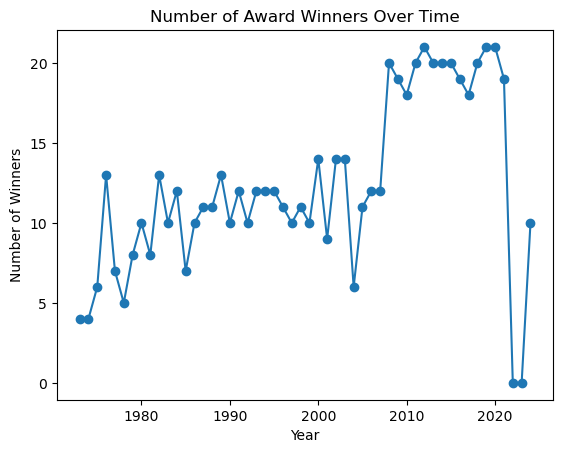

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

year_min = df_unique["year"].min()
year_max = df_unique["year"].max()
all_years = pd.Series(range(year_min, year_max + 1), name="year")

winners_per_year = df_unique.groupby("year").size()

winners_per_year = winners_per_year.reindex(all_years, fill_value=0)

plt.figure()
winners_per_year.plot(marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Number of Award Winners Over Time")
plt.show()

<Figure size 640x480 with 0 Axes>

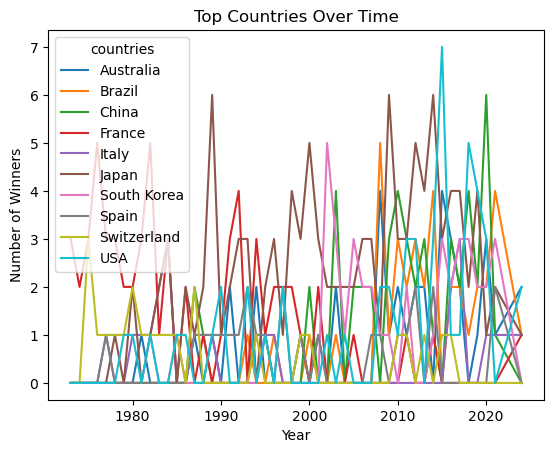

In [8]:
top_countries = df_unique["countries"].value_counts().head(10).index

df_top = df_unique[df_unique["countries"].isin(top_countries)]

country_year = df_top.groupby(["year", "countries"]).size().unstack(fill_value=0)

plt.figure()
country_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Top Countries Over Time")
plt.show()

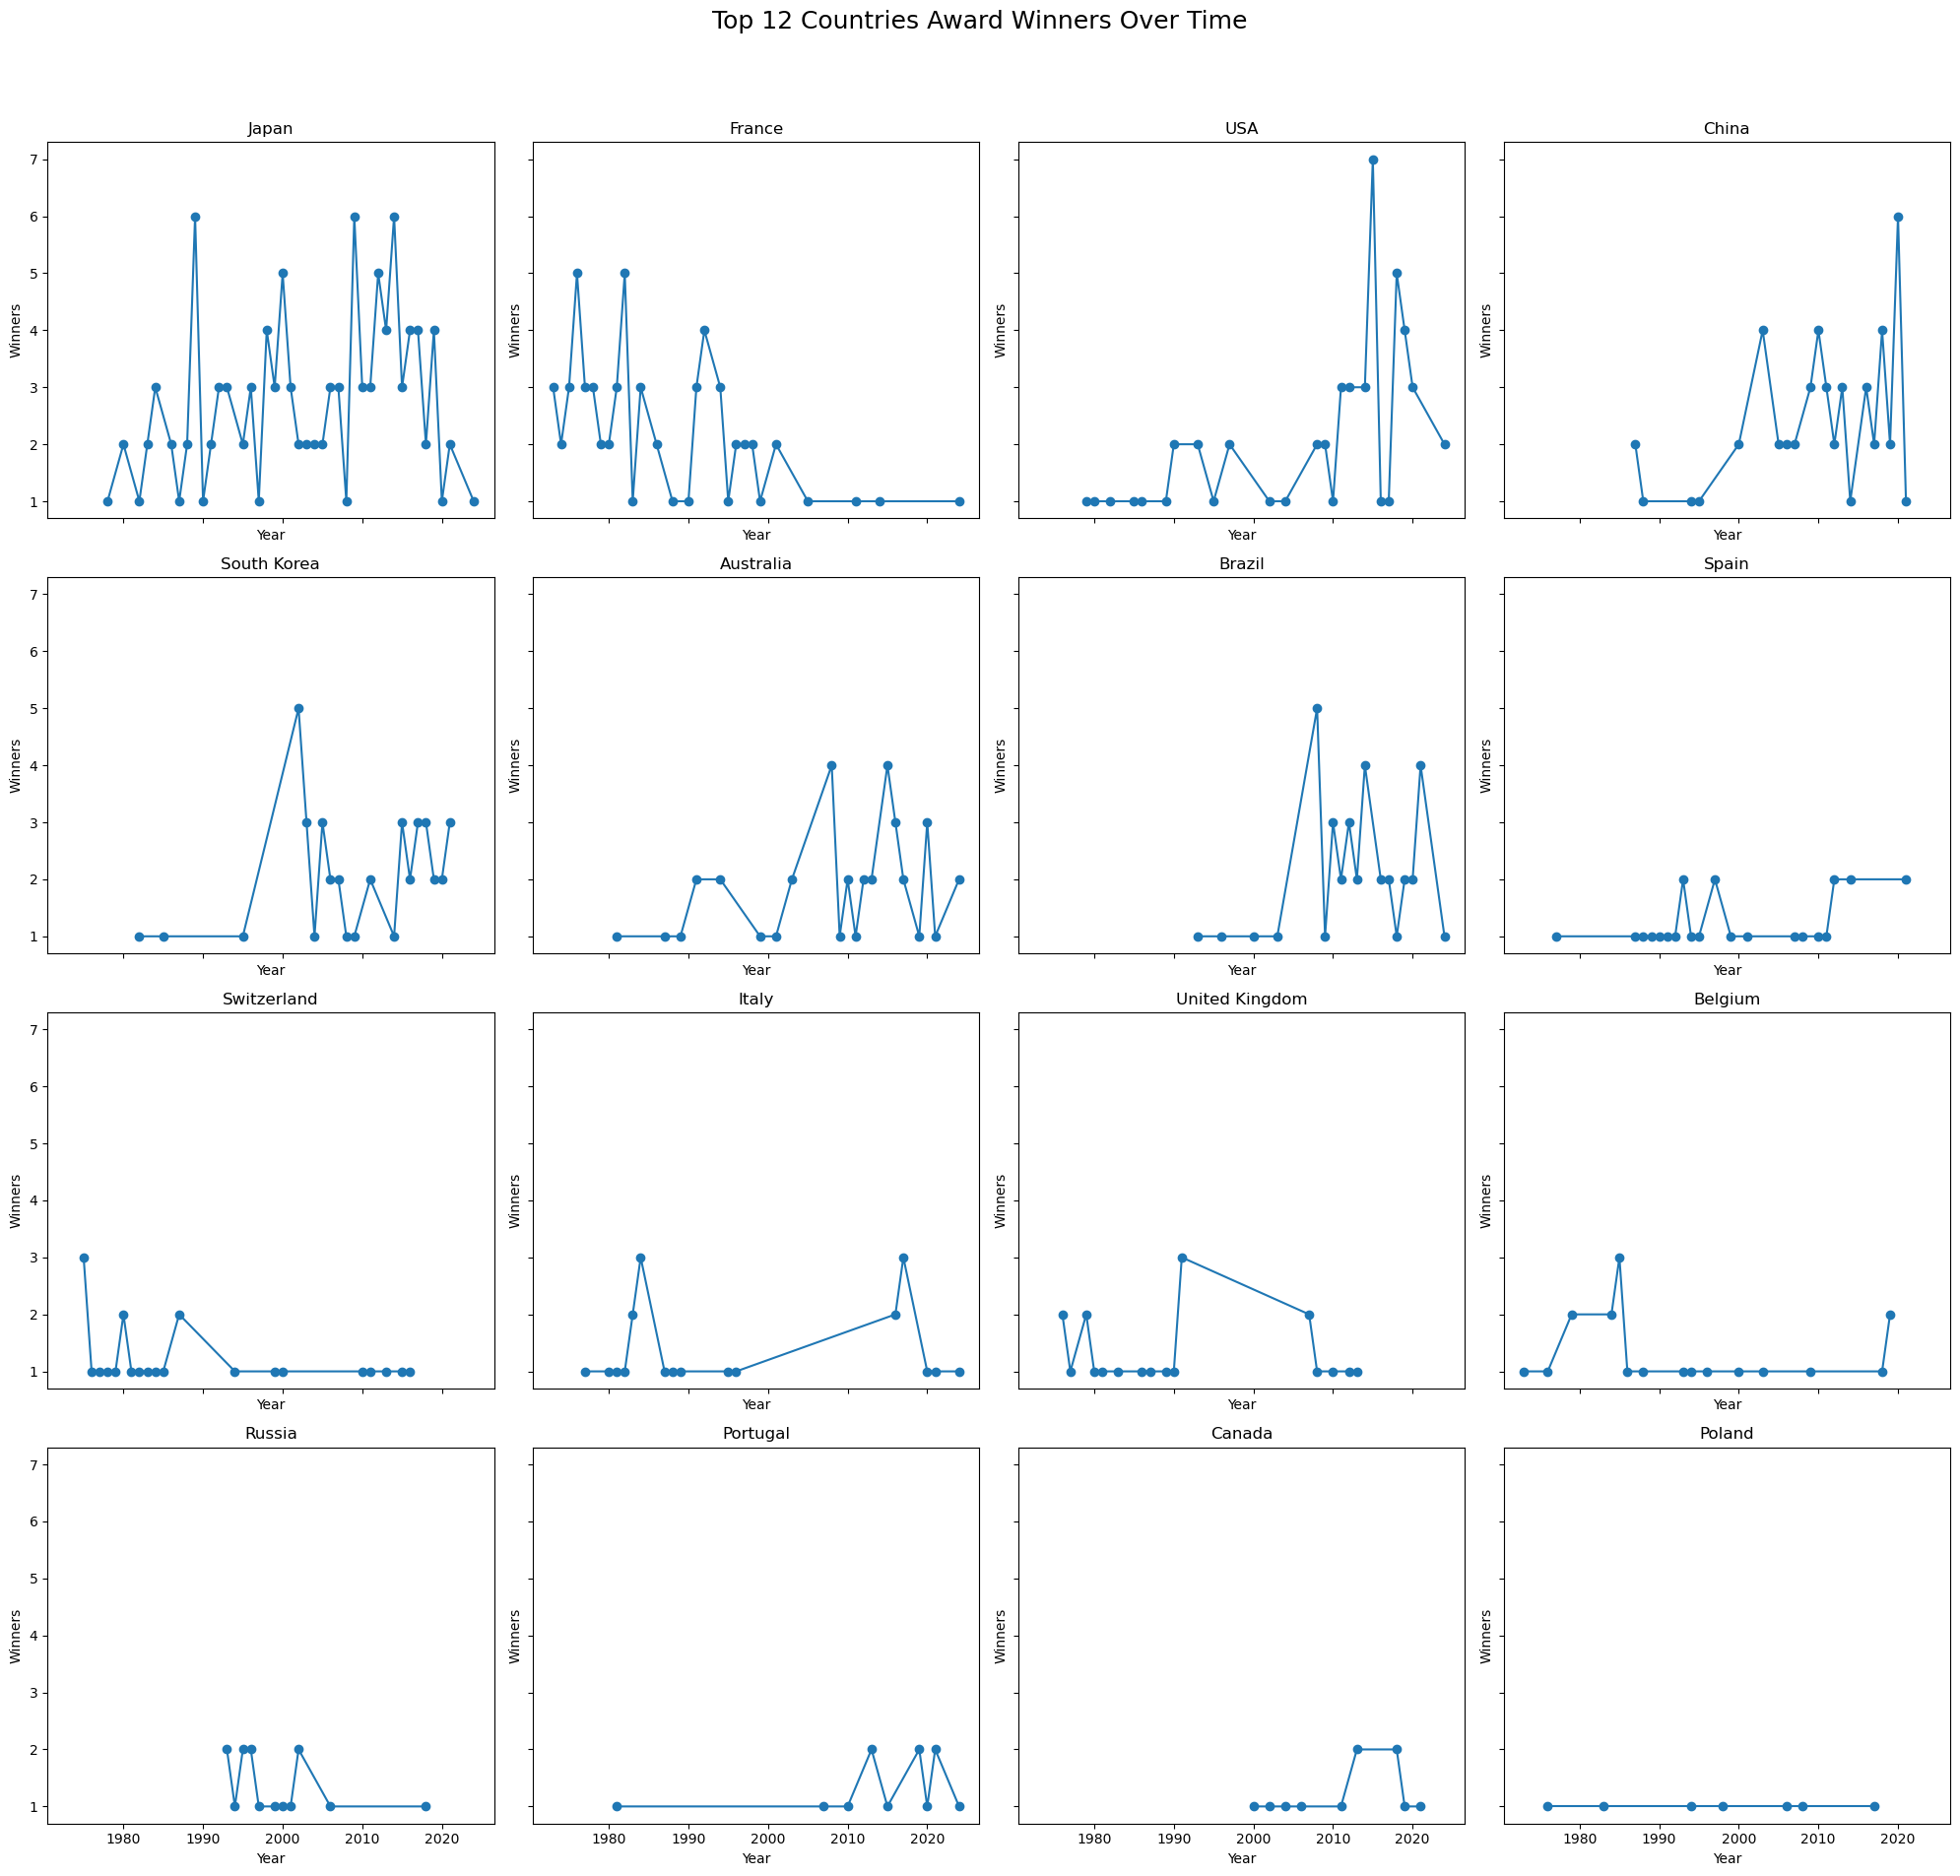

In [9]:
import matplotlib.pyplot as plt

# Top 16 countries
top_16_countries = df_unique["countries"].value_counts().head(16).index

# plot 4*4
fig, axes = plt.subplots(4, 4, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten() 

for i, country in enumerate(top_16_countries):
    data = df_unique[df_unique["countries"] == country]
    winners_per_year = data.groupby("year").size()
    
    axes[i].plot(winners_per_year.index, winners_per_year.values, marker='o')
    axes[i].set_title(country)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Winners")

plt.suptitle("Top 12 Countries Award Winners Over Time", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

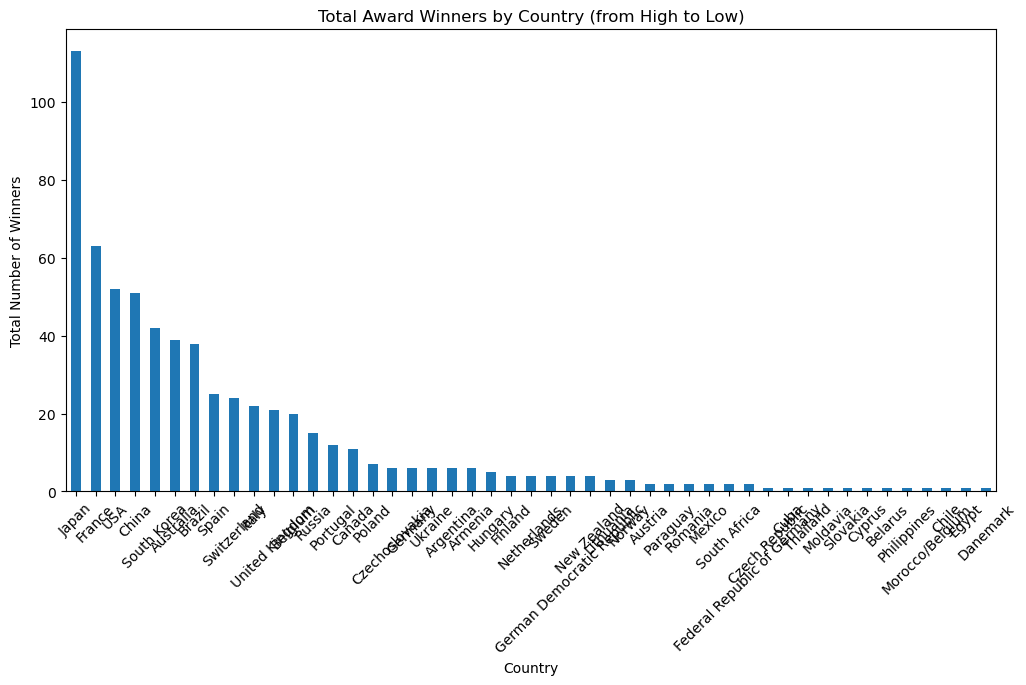

In [10]:
import matplotlib.pyplot as plt

country_counts = df_unique["countries"].value_counts()

plt.figure(figsize=(12, 6))
country_counts.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Total Number of Winners")
plt.title("Total Award Winners by Country (from High to Low)")
plt.xticks(rotation=45)
plt.show()

By decades

C:\Users\lenovo\AppData\Local\Temp\ipykernel_35136\4154812381.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'count'))


=== 1970s ===
['(France, 21)', '(Switzerland, 7)', '(United Kingdom, 5)']
=== 1980s ===
['(Japan, 19)', '(France, 17)', '(Italy, 11)']
=== 1990s ===
['(Japan, 22)', '(France, 19)', '(Spain, 10)']
=== 2000s ===
['(Japan, 29)', '(South Korea, 18)', '(China, 15)']
=== 2010s ===
['(Japan, 38)', '(USA, 28)', '(China, 24)']
=== 2020s ===
['(Brazil, 7)', '(China, 7)', '(Australia, 6)']


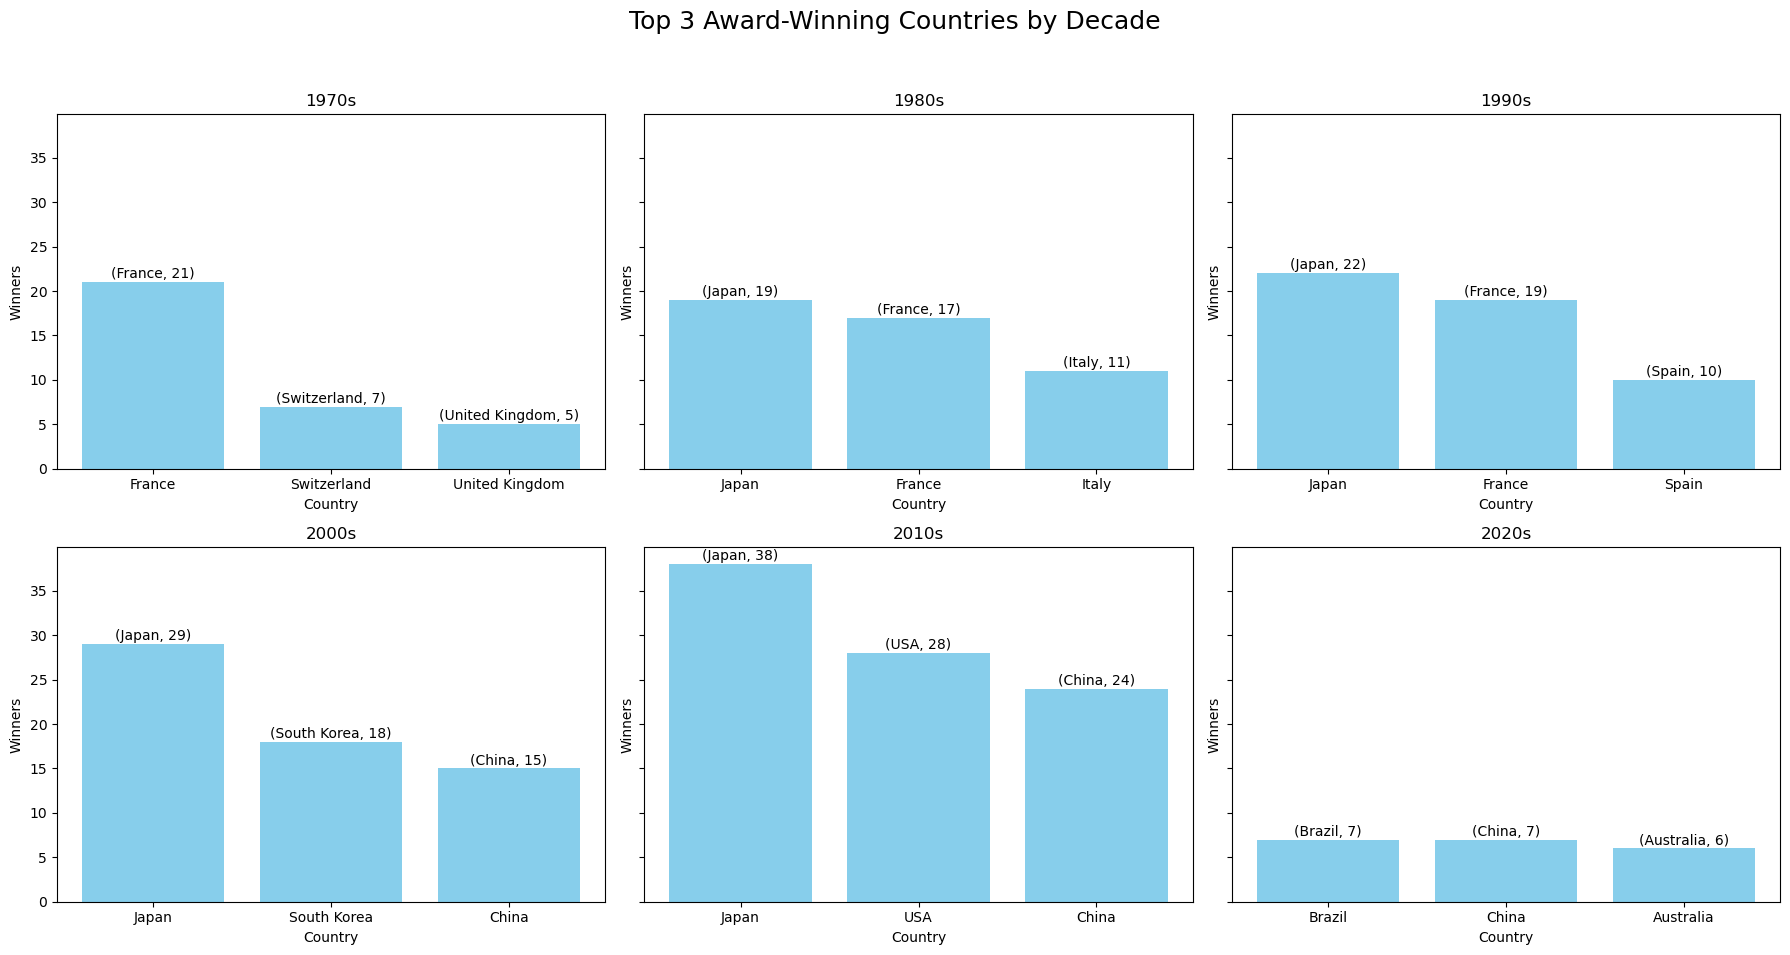

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df_unique = df_unique.copy()
df_unique['decade'] = (df_unique['year'] // 10) * 10

decade_country_counts = df_unique.groupby(['decade', 'countries']).size().reset_index(name='count')

top3_per_decade = (
    decade_country_counts.groupby('decade', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'count'))
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, decade in enumerate(sorted(top3_per_decade['decade'].unique())):
    df_decade = top3_per_decade[top3_per_decade['decade'] == decade]
    
    print(f"=== {decade}s ===")
    print([f"({row['countries']}, {row['count']})" for _, row in df_decade.iterrows()])
    
    bars = axes[i].bar(df_decade['countries'], df_decade['count'], color='skyblue')
    axes[i].set_title(f"{decade}s")
    axes[i].set_xlabel("Country")
    axes[i].set_ylabel("Winners")
    for bar, country, count in zip(bars, df_decade['countries'], df_decade['count']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"({country}, {count})", 
                     ha='center', va='bottom', fontsize=10)

plt.suptitle("Top 3 Award-Winning Countries by Decade", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 2.2 continent

In [12]:
unique_countries = df_unique['countries'].unique()
print(sorted(unique_countries))

['Argentina', 'Armenia', 'Australia', 'Austria', 'Belarus', 'Belgium', 'Brazil', 'Canada', 'Chile', 'China', 'Cuba', 'Cyprus', 'Czech Republic', 'Czechoslovakia', 'Danemark', 'Egypt', 'Federal Republic of Germany', 'Finland', 'France', 'German Democratic Republic', 'Germany', 'Hungary', 'Italy', 'Japan', 'Lithuania', 'Mexico', 'Moldavia', 'Morocco/Belgium', 'Netherlands', 'New Zealand', 'Norway', 'Paraguay', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'Ukraine', 'United Kingdom']


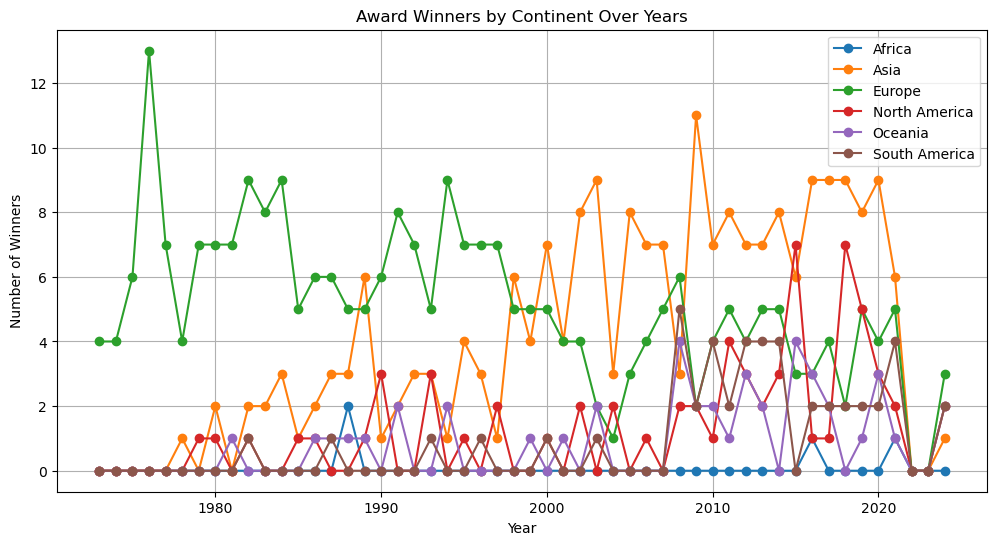

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

country_to_continent = {
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Brazil': 'South America',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Cuba': 'North America',
    'Cyprus': 'Europe',
    'Czech Republic': 'Europe',
    'Czechoslovakia': 'Europe',
    'Danemark': 'Europe',
    'Egypt': 'Africa',
    'Federal Republic of Germany': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'German Democratic Republic': 'Europe',
    'Germany': 'Europe',
    'Hungary': 'Europe',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Lithuania': 'Europe',
    'Mexico': 'North America',
    'Moldavia': 'Europe',
    'Morocco/Belgium': 'Africa',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Norway': 'Europe',
    'Paraguay': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Romania': 'Europe',
    'Russia': 'Europe',
    'Slovakia': 'Europe',
    'South Africa': 'Africa',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Thailand': 'Asia',
    'USA': 'North America',
    'Ukraine': 'Europe',
    'United Kingdom': 'Europe'
}

df_unique = df_unique.copy()
df_unique['continent'] = df_unique['countries'].map(country_to_continent)

all_years = range(df_unique['year'].min(), df_unique['year'].max()+1)

continent_year = df_unique.groupby(['year','continent']).size().unstack(fill_value=0)

continent_year = continent_year.reindex(all_years, fill_value=0)

plt.figure(figsize=(12,6))
for continent in continent_year.columns:
    plt.plot(continent_year.index, continent_year[continent], marker='o', label=continent)

plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Award Winners by Continent Over Years")
plt.legend()
plt.grid(True)
plt.show()

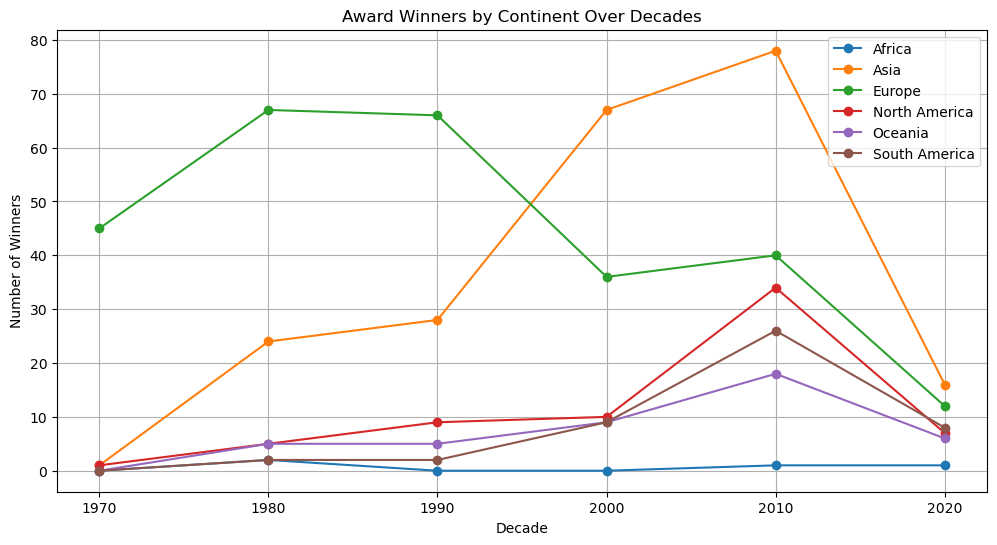

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

country_to_continent = {
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Brazil': 'South America',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Cuba': 'North America',
    'Cyprus': 'Europe',
    'Czech Republic': 'Europe',
    'Czechoslovakia': 'Europe',
    'Danemark': 'Europe',
    'Egypt': 'Africa',
    'Federal Republic of Germany': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'German Democratic Republic': 'Europe',
    'Germany': 'Europe',
    'Hungary': 'Europe',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Lithuania': 'Europe',
    'Mexico': 'North America',
    'Moldavia': 'Europe',
    'Morocco/Belgium': 'Africa',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Norway': 'Europe',
    'Paraguay': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Romania': 'Europe',
    'Russia': 'Europe',
    'Slovakia': 'Europe',
    'South Africa': 'Africa',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Thailand': 'Asia',
    'USA': 'North America',
    'Ukraine': 'Europe',
    'United Kingdom': 'Europe'
}

df_unique = df_unique.copy()
df_unique['continent'] = df_unique['countries'].map(country_to_continent)
df_unique['decade'] = (df_unique['year'] // 10) * 10

continent_decade = df_unique.groupby(['decade','continent']).size().unstack(fill_value=0)

all_decades = range(df_unique['decade'].min(), df_unique['decade'].max()+10, 10)
continent_decade = continent_decade.reindex(all_decades, fill_value=0)

plt.figure(figsize=(12,6))
for continent in continent_decade.columns:
    plt.plot(continent_decade.index, continent_decade[continent], marker='o', label=continent)

plt.xlabel("Decade")
plt.ylabel("Number of Winners")
plt.title("Award Winners by Continent Over Decades")
plt.legend()
plt.grid(True)
plt.show()

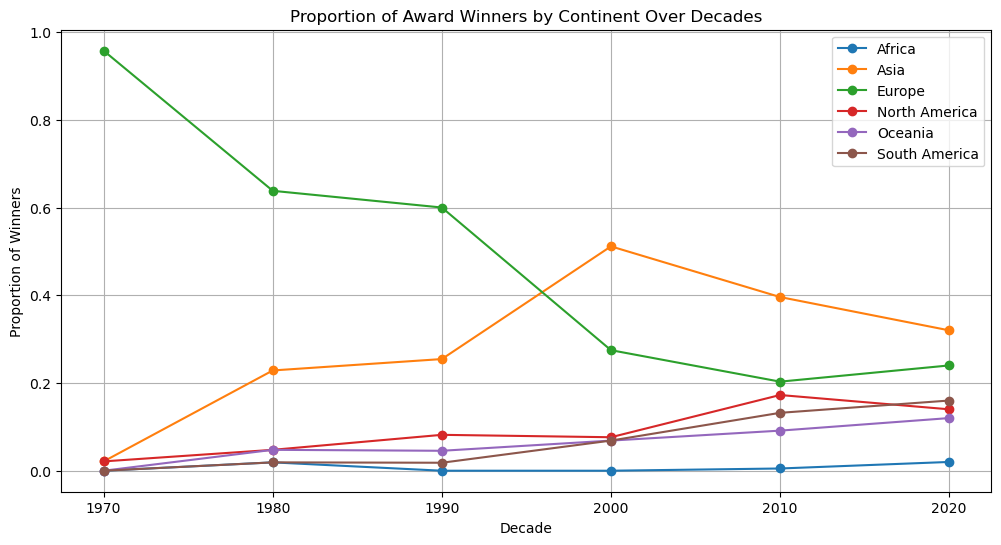

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

country_to_continent = {
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Brazil': 'South America',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Cuba': 'North America',
    'Cyprus': 'Europe',
    'Czech Republic': 'Europe',
    'Czechoslovakia': 'Europe',
    'Danemark': 'Europe',
    'Egypt': 'Africa',
    'Federal Republic of Germany': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'German Democratic Republic': 'Europe',
    'Germany': 'Europe',
    'Hungary': 'Europe',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Lithuania': 'Europe',
    'Mexico': 'North America',
    'Moldavia': 'Europe',
    'Morocco/Belgium': 'Africa',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Norway': 'Europe',
    'Paraguay': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Romania': 'Europe',
    'Russia': 'Europe',
    'Slovakia': 'Europe',
    'South Africa': 'Africa',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Thailand': 'Asia',
    'USA': 'North America',
    'Ukraine': 'Europe',
    'United Kingdom': 'Europe'
}

df_unique = df_unique.copy()
df_unique['continent'] = df_unique['countries'].map(country_to_continent)
df_unique['decade'] = (df_unique['year'] // 10) * 10

continent_decade = df_unique.groupby(['decade','continent']).size().unstack(fill_value=0)

all_decades = range(df_unique['decade'].min(), df_unique['decade'].max()+10, 10)
continent_decade = continent_decade.reindex(all_decades, fill_value=0)

continent_decade_prop = continent_decade.div(continent_decade.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
for continent in continent_decade_prop.columns:
    plt.plot(continent_decade_prop.index, continent_decade_prop[continent], marker='o', label=continent)

plt.xlabel("Decade")
plt.ylabel("Proportion of Winners")
plt.title("Proportion of Award Winners by Continent Over Decades")
plt.legend()
plt.grid(True)
plt.show()

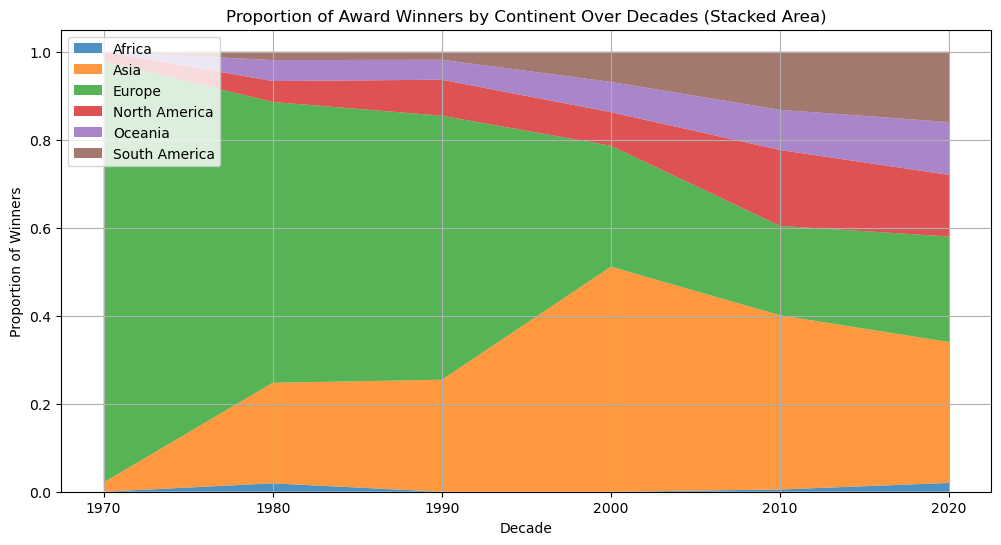

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df_unique['decade'] = (df_unique['year'] // 10) * 10
continent_decade = df_unique.groupby(['decade','continent']).size().unstack(fill_value=0)

all_decades = range(df_unique['decade'].min(), df_unique['decade'].max()+10, 10)
continent_decade = continent_decade.reindex(all_decades, fill_value=0)

continent_decade_prop = continent_decade.div(continent_decade.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.stackplot(
    continent_decade_prop.index,
    [continent_decade_prop[col] for col in continent_decade_prop.columns],  
    labels=continent_decade_prop.columns,
    alpha=0.8
)

plt.xlabel("Decade")
plt.ylabel("Proportion of Winners")
plt.title("Proportion of Award Winners by Continent Over Decades (Stacked Area)")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# 3. Gender

In [16]:
!pip install gender-guesser

In [17]:
import gender_guesser.detector as gender
d = gender.Detector()

df_unique['gender'] = df_unique['name'].apply(lambda x: d.get_gender(x.split()[0]))

In [18]:
gender_counts = df_unique['gender'].value_counts()
print(gender_counts)

gender
female           234
male             215
unknown          127
andy              31
mostly_female     19
mostly_male       14
Name: count, dtype: int64


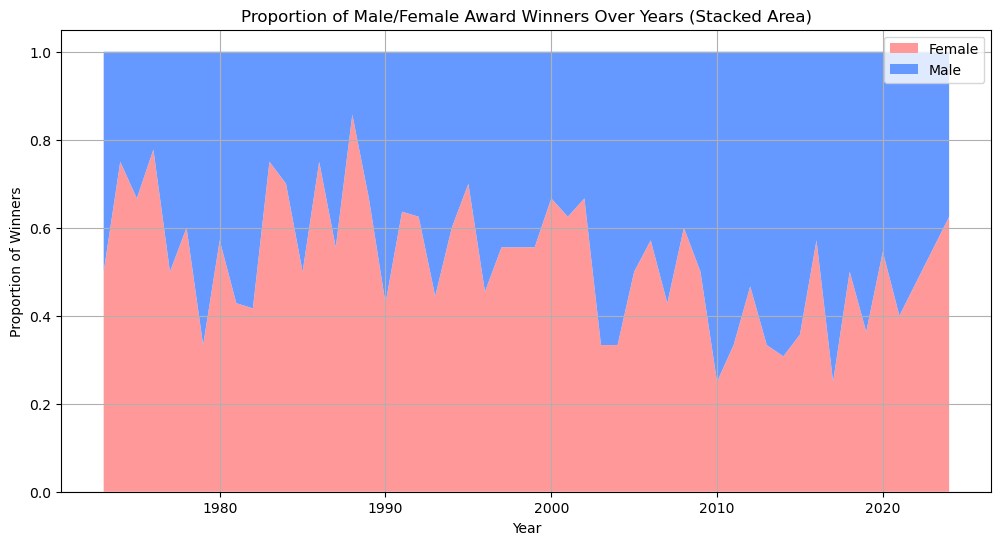

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df_unique['gender_clean'] = df_unique['gender'].replace(
    ['andy', 'mostly_female', 'mostly_male', 'unknown'], 'Unknown'
)

gender_year = df_unique.groupby(['year','gender_clean']).size().unstack(fill_value=0)
gender_year = gender_year[['female','male']]
gender_year_prop = gender_year.div(gender_year.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.stackplot(
    gender_year_prop.index,
    gender_year_prop['female'],
    gender_year_prop['male'],
    labels=['Female','Male'],
    colors=['#ff9999','#6699ff']
)

plt.xlabel("Year")
plt.ylabel("Proportion of Winners")
plt.title("Proportion of Male/Female Award Winners Over Years (Stacked Area)")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

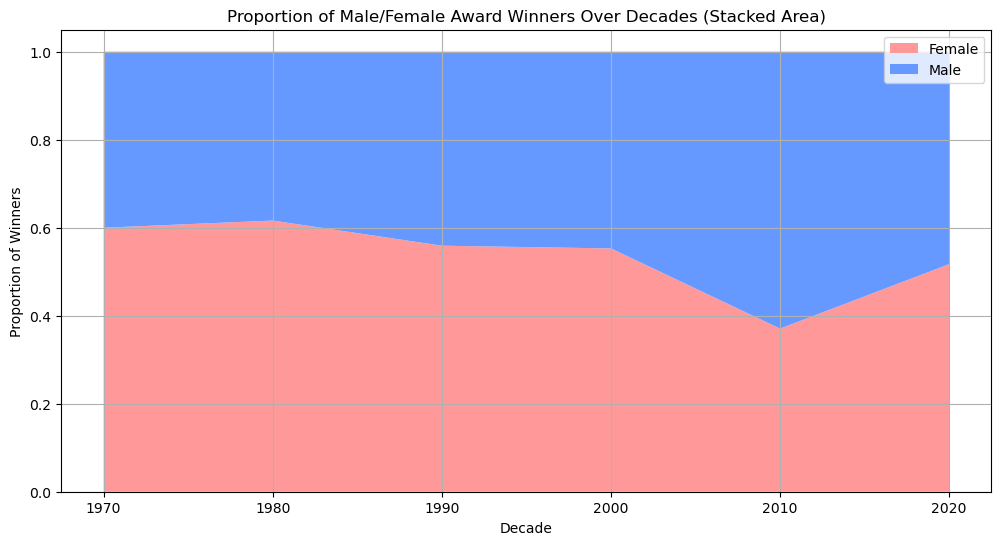

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df_unique['gender_clean'] = df_unique['gender'].replace(
    ['andy', 'mostly_female', 'mostly_male', 'unknown'], 'Unknown'
)

df_unique['decade'] = (df_unique['year'] // 10) * 10

gender_decade = df_unique.groupby(['decade','gender_clean']).size().unstack(fill_value=0)
gender_decade = gender_decade[['female','male']]
gender_decade_prop = gender_decade.div(gender_decade.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.stackplot(
    gender_decade_prop.index,
    gender_decade_prop['female'],
    gender_decade_prop['male'],
    labels=['Female','Male'],
    colors=['#ff9999','#6699ff']
)

plt.xlabel("Decade")
plt.ylabel("Proportion of Winners")
plt.title("Proportion of Male/Female Award Winners Over Decades (Stacked Area)")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [23]:
df_unique.to_excel("data_Prix_unique_processed_2025.xlsx", index=False)